# Order Book Analysis & Liquidity Modeling

**Goal:** Parse high-frequency Level-2 order book data and quantify real-time
liquidity — bid-ask spreads, depth profiles, and liquidity heatmaps — plus
**Order Flow Imbalance (OFI)** as a short-horizon alpha signal, a
**signal-to-strategy backtest**, and **slippage / price-impact** modeling.

This notebook imports the small `orderbook` package that lives alongside it
(`orderbook/data.py`, `metrics.py`, `ofi.py`, `impact.py`,
`signal_backtest.py`, `binance_loader.py`). The same modules also power the
command-line tool `main.py`.

**Sections**
1. Setup & data (synthetic with realistic OFI, or load real CSV)
2. Bid-ask spread
3. Depth profile & cumulative depth curve
4. Liquidity heatmap (time x level)
5. Book imbalance at the top
6. Order Flow Imbalance (OFI) — predictive signal
7. **Signal-to-strategy backtest** — OFI -> long/short -> P&L
8. Slippage curve & square-root impact model
9. Capturing real data from Binance (ready-to-run)
10. Takeaways


In [1]:
# Make sure the local `orderbook` package is importable.
import sys, os
sys.path.insert(0, os.getcwd())

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

# Font hygiene (English-only notebook, but keep symbols clean)
try:
    fm.fontManager.addfont('/usr/share/fonts/truetype/dejavu/DejaVuSans.ttf')
except Exception:
    pass
plt.rcParams['font.sans-serif'] = ['DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 110

from orderbook.data import BookParams, generate_synthetic_l2, load_l2_csv
from orderbook.metrics import (
    bid_ask_spread, depth_at_top_n, mean_size_per_level,
    cumulative_depth_curve, liquidity_heatmap, book_imbalance,
)
from orderbook.ofi import compute_ofi, ofi_summary_stats
from orderbook.impact import walk_the_book_slippage, square_root_impact
from orderbook.signal_backtest import ofi_backtest, BacktestConfig, print_backtest_summary

print('Imports OK')


Imports OK


## 1. Setup & data

We use the synthetic Level-2 generator by default. It produces books that
share the *stylised facts* of real L2 feeds:

- Mid-price follows a geometric random walk (log-returns ~ N(0, sigma)).
- Spread is sticky, an integer multiple of the tick size, ~ Poisson.
- Size at each level decays exponentially with depth.
- Sizes are perturbed with multiplicative log-normal noise.

**Realistic OFI mode (on by default).** A latent "pressure" AR(1) process
drives BOTH queue changes at the top of the book AND the next snapshot's
mid return. This makes OFI predictive of short-horizon returns — exactly
the empirical regularity Cont, Kukanov & Stoikov (2014) document on real
data. Set `realistic_ofi=False` to revert to the null case (uncorrelated
queues and returns) for sanity-checking.

If you have your own L2 CSV with columns
`timestamp, level, bid_price, bid_qty, ask_price, ask_qty`, swap the call
below for `load_l2_csv('path/to/file.csv')` and everything downstream
works unchanged. See Section 9 for how to capture real Binance data.


In [2]:
# Generate synthetic L2 data.
# Tweak these to mimic a different asset class — examples in the docstring
# of BookParams (crypto / equities / futures).
params = BookParams(
    n_ticks=5_000,         # number of snapshots
    n_levels=20,           # depth levels per side
    tick_size=0.01,        # minimum price increment
    init_mid=100.0,        # starting mid price
    vol_per_tick=2e-3,     # per-snapshot mid log-return volatility
    base_qty=1.0,          # size at top of book
    qty_decay=0.85,        # exponential decay per level
    qty_noise=0.30,        # multiplicative noise on size
    spread_ticks_mean=2,   # mean spread in ticks
    realistic_ofi=True,    # inject OFI <-> return predictive content
    pressure_ar_coef=0.85, # AR(1) persistence of latent pressure
    pressure_to_qty=0.40,  # how strongly pressure biases queue changes
    pressure_to_return=0.50, # how strongly pressure drives next return
    seed=42,
)

df = generate_synthetic_l2(params)
print(f'Rows: {len(df):,}  |  Snapshots: {df.timestamp.nunique():,}  |  Levels/side: {df.level.nunique()}')
df.head(10)


Rows: 100,000  |  Snapshots: 5,000  |  Levels/side: 20


,timestamp,level,bid_price,bid_qty,ask_price,ask_qty,mid,spread
0,0,0,99.81,0.768373,99.83,0.778240,99.821613,0.02
1,0,1,99.80,1.473334,99.84,0.859286,99.821613,0.02
2,0,2,99.79,0.541005,99.85,1.154210,99.821613,0.02
3,0,3,99.78,0.451069,99.86,0.742151,99.821613,0.02
4,0,4,99.77,0.386059,99.87,0.771643,99.821613,0.02
5,0,5,99.76,0.426555,99.88,0.740959,99.821613,0.02
6,0,6,99.75,0.207957,99.89,0.343720,99.821613,0.02
7,0,7,99.74,0.208552,99.90,0.290425,99.821613,0.02
8,0,8,99.73,0.226083,99.91,0.274720,99.821613,0.02
9,0,9,99.72,0.161791,99.92,0.121990,99.821613,0.02


In [3]:
# Quick sanity check: a single snapshot's top 5 levels.
df[df.timestamp == 0].head(5)


,timestamp,level,bid_price,bid_qty,ask_price,ask_qty,mid,spread
0,0,0,99.81,0.768373,99.83,0.778240,99.821613,0.02
1,0,1,99.80,1.473334,99.84,0.859286,99.821613,0.02
2,0,2,99.79,0.541005,99.85,1.154210,99.821613,0.02
3,0,3,99.78,0.451069,99.86,0.742151,99.821613,0.02
4,0,4,99.77,0.386059,99.87,0.771643,99.821613,0.02


## 2. Bid-ask spread

The spread is the simplest liquidity metric: `best_ask - best_bid`. We
report it in three units:

- **abs** — price units
- **ticks** — multiples of the tick size (most natural for exchange data)
- **bps** — basis points relative to the mid (asset-normalised)

A tight, stable spread is the signature of a liquid market. Wide or
spiky spreads typically coincide with news / volatility shocks.


In [4]:
spread_df = bid_ask_spread(df, tick_size=params.tick_size)
spread_df.describe().T


,count,mean,std,min,25%,50%,75%,max
timestamp,5000.0,2499.500000,1443.520003,0.000000,1249.750000,2499.500000,3749.250000,4999.000000
mid,5000.0,73.326740,14.517822,50.643542,61.358986,69.405628,88.312363,104.385778
spread_abs,5000.0,0.021328,0.012521,0.010000,0.010000,0.020000,0.030000,0.080000
spread_ticks,5000.0,2.132800,1.252149,1.000000,1.000000,2.000000,3.000000,8.000000
spread_bps,5000.0,3.021051,1.890442,0.957985,1.524224,2.551708,3.944140,13.768754


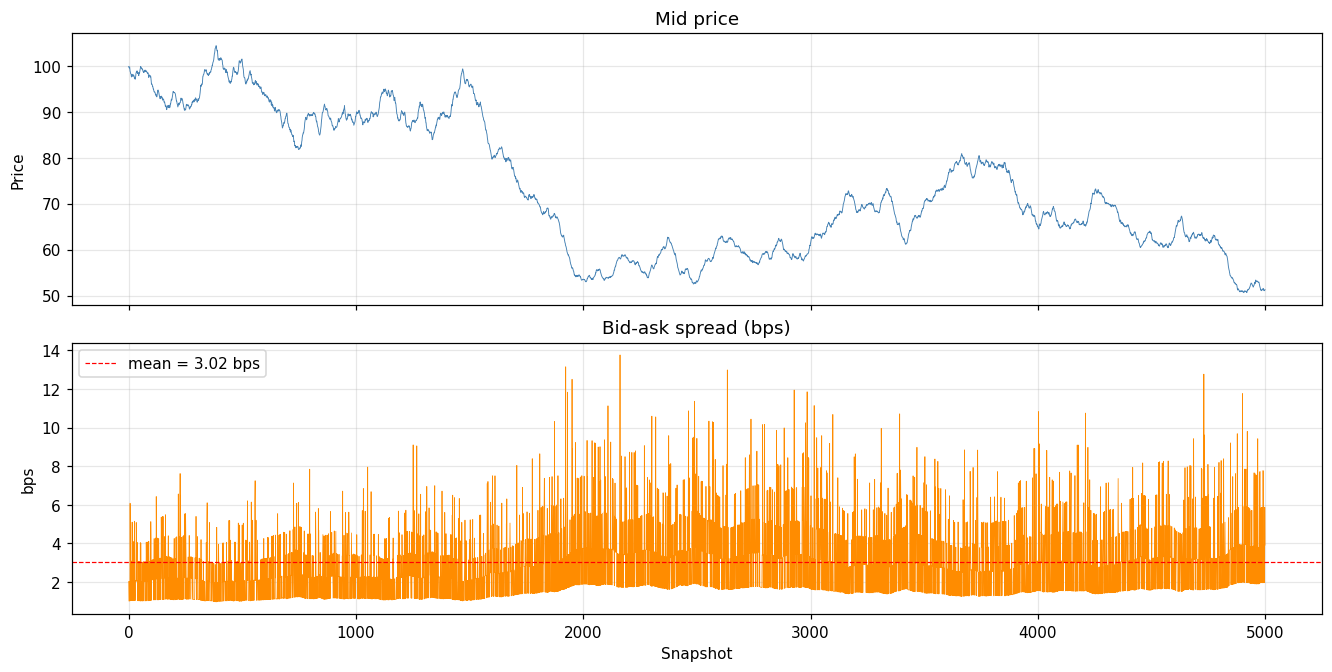

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(12, 6), constrained_layout=True, sharex=True)

axes[0].plot(spread_df.timestamp, spread_df.mid, color='steelblue', lw=0.6)
axes[0].set_title('Mid price')
axes[0].set_ylabel('Price')
axes[0].grid(alpha=0.3)

axes[1].plot(spread_df.timestamp, spread_df.spread_bps, color='darkorange', lw=0.5)
mean_bps = spread_df.spread_bps.mean()
axes[1].axhline(mean_bps, color='red', ls='--', lw=0.8, label=f'mean = {mean_bps:.2f} bps')
axes[1].set_title('Bid-ask spread (bps)')
axes[1].set_ylabel('bps')
axes[1].set_xlabel('Snapshot')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.show()


**Reading the chart.** The mid-price random-walks around 100; the spread
hovers near its mean with occasional excursions when the Poisson spread
process jumps. On real data the same chart will show intraday seasonality
— spreads typically widen at the open and close.

## 3. Depth profile & cumulative depth curve

The spread tells you only about the *top* of the book. Depth tells you
how much size is available as you walk away from the top. We measure:

- **Average size per level** (bid vs ask side by side)
- **Cumulative depth curve** — running sum of size as we include more levels

Cumulative depth at level *L* answers the practical question: *"How many
units can I clear if I sweep levels 0..L?"* — which is exactly what a
marketable order does.


In [6]:
depth_top = depth_at_top_n(df, n=5)
print('Top-5 mean depth:')
depth_top[['bid_depth', 'ask_depth', 'total_depth']].mean().to_frame('mean')


Top-5 mean depth:


,mean
bid_depth,4.327557
ask_depth,4.693082
total_depth,9.020640


In [7]:
# Two views of depth: per-level means + cumulative running sum
mean_size_df = mean_size_per_level(df)   # for the per-level bar chart
cum_df = cumulative_depth_curve(df)      # adds cumulative sums for the line chart
cum_df.head(10)


,level,bid_qty,ask_qty,cum_bid,cum_ask,cum_total
0,0,1.321161,1.481506,1.321161,1.481506,2.802667
1,1,1.000382,1.094188,2.321542,2.575694,4.897236
2,2,0.799008,0.853250,3.120550,3.428944,6.549494
3,3,0.657323,0.693809,3.777874,4.122753,7.900627
4,4,0.549683,0.570330,4.327557,4.693082,9.020640
5,5,0.466438,0.477567,4.793995,5.170650,9.964645
6,6,0.391959,0.399173,5.185954,5.569823,10.755777
7,7,0.334442,0.341616,5.520396,5.911439,11.431835
8,8,0.285499,0.285849,5.805895,6.197288,12.003182
9,9,0.241812,0.245575,6.047707,6.442862,12.490569


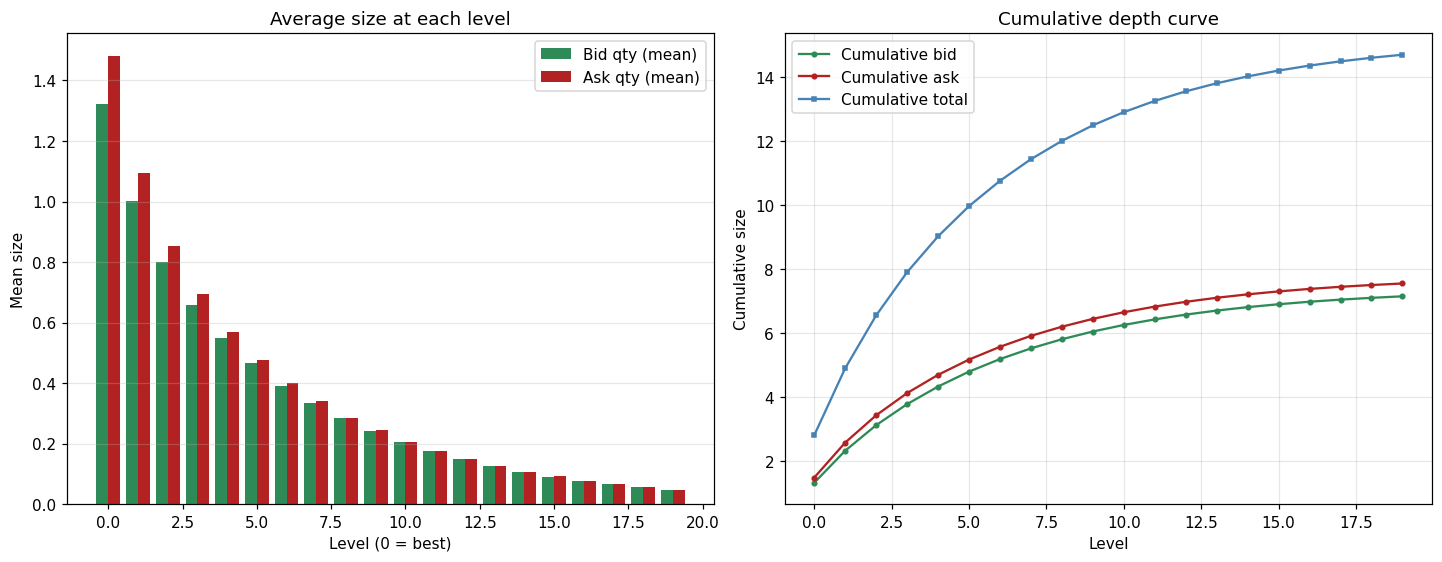

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), constrained_layout=True)

axes[0].bar(mean_size_df.level - 0.2, mean_size_df.bid_qty, width=0.4, color='seagreen', label='Bid qty (mean)')
axes[0].bar(mean_size_df.level + 0.2, mean_size_df.ask_qty, width=0.4, color='firebrick', label='Ask qty (mean)')
axes[0].set_title('Average size at each level')
axes[0].set_xlabel('Level (0 = best)')
axes[0].set_ylabel('Mean size')
axes[0].legend()
axes[0].grid(alpha=0.3, axis='y')

axes[1].plot(cum_df.level, cum_df.cum_bid, color='seagreen', marker='o', ms=3, label='Cumulative bid')
axes[1].plot(cum_df.level, cum_df.cum_ask, color='firebrick', marker='o', ms=3, label='Cumulative ask')
axes[1].plot(cum_df.level, cum_df.cum_total, color='steelblue', marker='s', ms=3, label='Cumulative total')
axes[1].set_title('Cumulative depth curve')
axes[1].set_xlabel('Level')
axes[1].set_ylabel('Cumulative size')
axes[1].legend()
axes[1].grid(alpha=0.3)
plt.show()


**Reading the chart.** The size profile decays roughly geometrically
(`qty_decay = 0.85` here), so most available liquidity sits in the top 3–5
levels. The cumulative curve flattens as we go deeper — a convex shape is
typical of healthy books. A flat or *concave* cumulative curve on real
data is a red flag (sparse book, possible stress).

## 4. Liquidity heatmap (time x level)

Instead of collapsing across time, the heatmap keeps *both* dimensions:
each cell is the average size in a (time-bin, level) bucket. Bright bands
= deep liquidity; dark bands = thin liquidity.

This is the single best chart for spotting **liquidity regimes** — e.g.
quiet periods vs stressed periods where the entire book thins out
simultaneously.


In [9]:
heat = liquidity_heatmap(df, n_levels=min(20, params.n_levels), n_bins=50)
print(f'Heatmap shape: {heat.shape}  (time_bins x levels)')
heat.iloc[:5, :8]   # peek at top-left corner


Heatmap shape: (50, 20)  (time_bins x levels)


level,0,1,2,3,4,5,6,7
time_bin,,,,,,,,
0,2.334774,1.961583,1.657302,1.322762,1.077627,0.937552,0.809974,0.695765
1,2.521008,2.088598,1.600102,1.314241,1.103184,0.933023,0.800393,0.665201
2,2.581429,2.023004,1.585346,1.320355,1.080751,0.972377,0.813888,0.670004
3,2.960514,2.101990,1.643517,1.381974,1.127978,0.901841,0.807966,0.675231
4,2.891780,2.089443,1.672750,1.334786,1.132273,0.970767,0.781838,0.676951


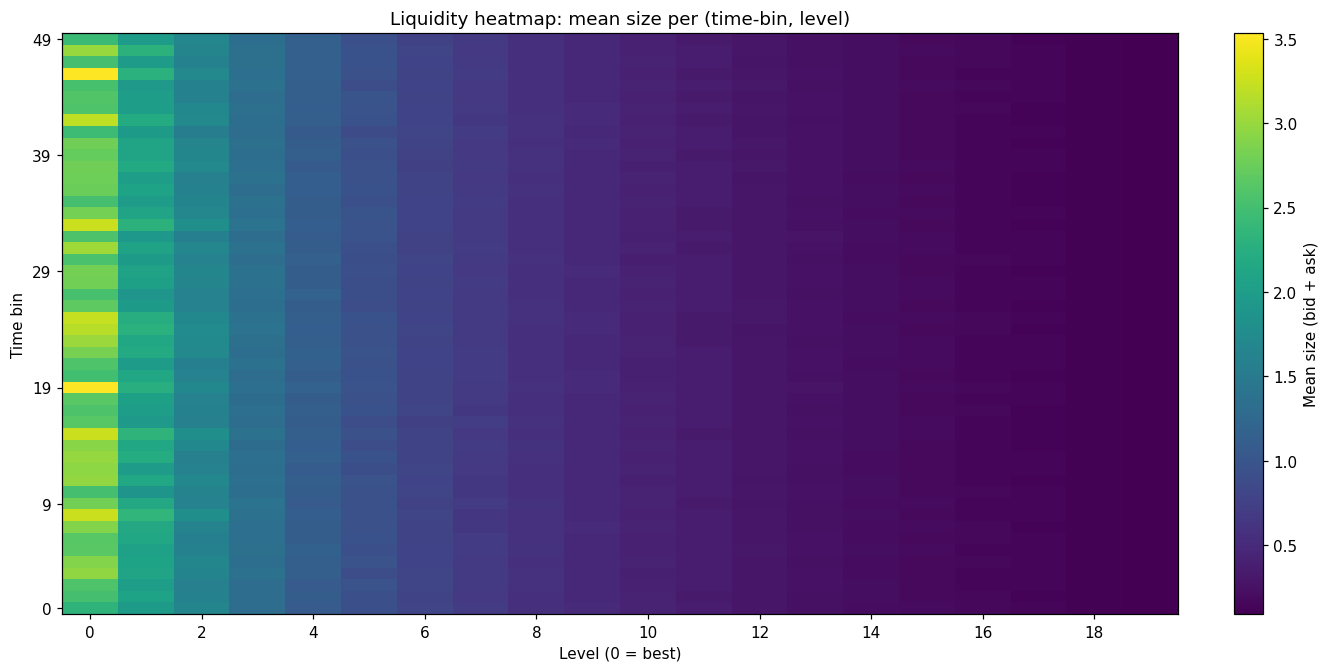

In [10]:
fig, ax = plt.subplots(figsize=(12, 6), constrained_layout=True)
im = ax.imshow(heat.values, aspect='auto', origin='lower',
               cmap='viridis', interpolation='nearest')
ax.set_title('Liquidity heatmap: mean size per (time-bin, level)')
ax.set_xlabel('Level (0 = best)')
ax.set_ylabel('Time bin')
ax.set_xticks(np.arange(0, heat.shape[1], max(1, heat.shape[1] // 10)))
ax.set_yticks(np.linspace(0, heat.shape[0] - 1, 6).astype(int))
fig.colorbar(im, ax=ax, label='Mean size (bid + ask)')
plt.show()


## 5. Book imbalance at the top

Top-N imbalance = `(bid_depth - ask_depth) / (bid_depth + ask_depth)`.
Range: -1 (all ask) to +1 (all bid).

It is a coarse but useful **directional pressure** proxy. Many trading
signals use the smoothed imbalance as a slow mean-reversion or fast
momentum input.


Mean imbalance: -0.0285
Std  imbalance: +0.4248


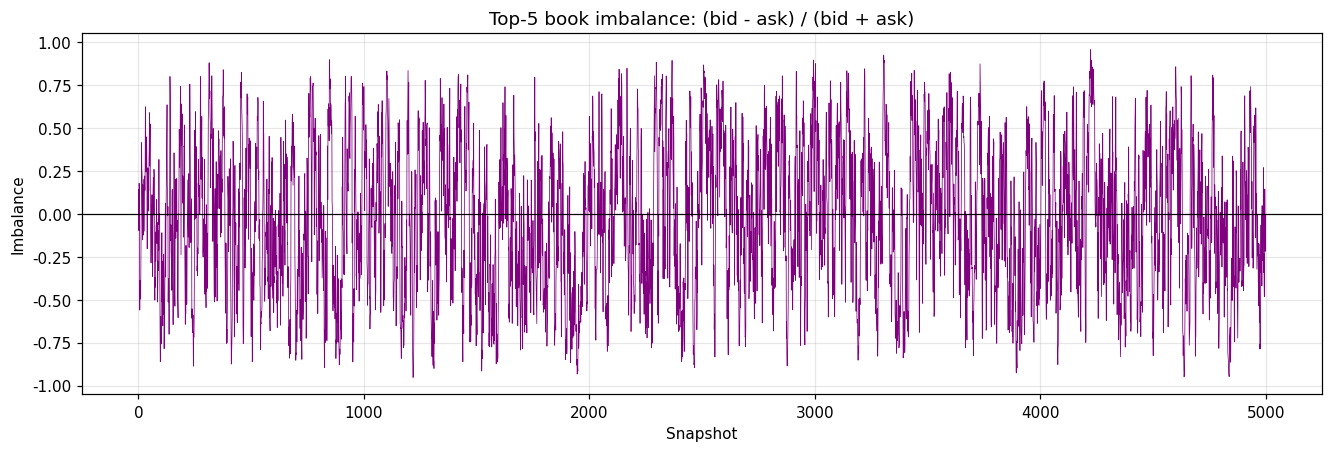

In [11]:
imb_df = book_imbalance(df, n=5)
print(f'Mean imbalance: {imb_df.imbalance.mean():+.4f}')
print(f'Std  imbalance: {imb_df.imbalance.std():+.4f}')

fig, ax = plt.subplots(figsize=(12, 4), constrained_layout=True)
ax.plot(imb_df.timestamp, imb_df.imbalance, color='purple', lw=0.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_title('Top-5 book imbalance: (bid - ask) / (bid + ask)')
ax.set_xlabel('Snapshot')
ax.set_ylabel('Imbalance')
ax.set_ylim(-1.05, 1.05)
ax.grid(alpha=0.3)
plt.show()


## 6. Order Flow Imbalance (OFI)

OFI (Cont, Kukanov & Stoikov, 2014) is the workhorse microstructure
signal for short-horizon price prediction:

```
OFI(t) = sum over top-L levels of [ dBidQty(t) - dAskQty(t) ]
```

Intuition: when the bid queue grows and the ask queue shrinks, buyers
are adding aggressiveness / sellers pulling it => upward pressure. The
empirical regularity (documented across stocks, futures, and crypto) is
that OFI is positively correlated with **short-horizon** mid returns —
typically 0.2-0.5 on liquid assets.

We measure `corr(OFI(t), mid_ret(t+1))` — the *lagged* correlation,
so we capture predictive content, not contemporaneous. With
`realistic_ofi=True` (default), our synthetic generator reproduces
this regularity; with `realistic_ofi=False` it gives a clean null
(near-zero correlation) for sanity-checking.


In [12]:
ofi_df, corr = compute_ofi(df, n_levels=10)
print(f'corr(OFI_t, mid_ret_{{t+1}}) = {corr:+.4f}')
ofi_summary_stats(ofi_df)


corr(OFI_t, mid_ret_{t+1}) = +0.1647


,ofi_mean,ofi_std,ofi_skew,ofi_kurt,ofi_roll50_mean,ofi_roll50_std
0,0.000348,3.262791,0.121001,1.860152,-0.00273,7.428964


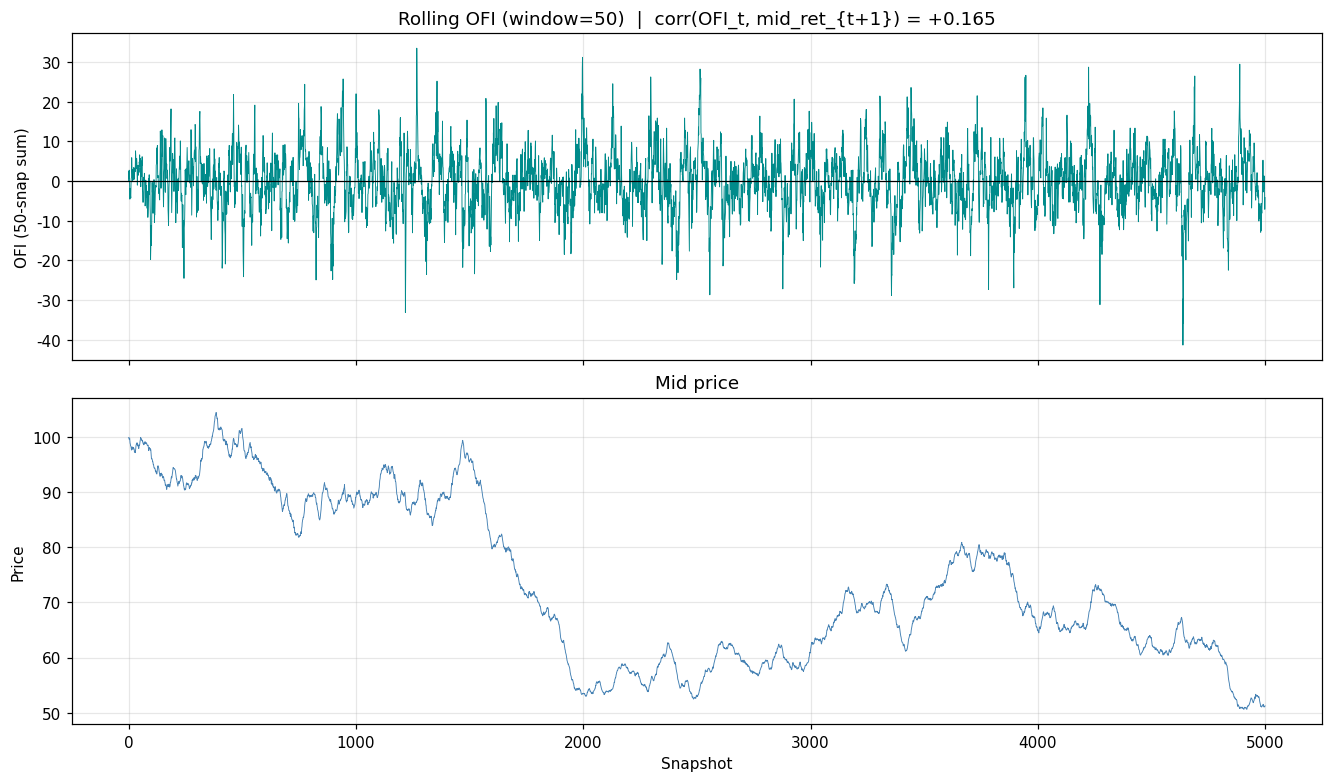

In [13]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), constrained_layout=True, sharex=True)

axes[0].plot(ofi_df.timestamp, ofi_df.ofi_roll_50, color='darkcyan', lw=0.6)
axes[0].axhline(0, color='black', lw=0.8)
axes[0].set_title(f'Rolling OFI (window=50)  |  corr(OFI_t, mid_ret_{{t+1}}) = {corr:+.3f}')
axes[0].set_ylabel('OFI (50-snap sum)')
axes[0].grid(alpha=0.3)

axes[1].plot(ofi_df.timestamp, ofi_df.mid, color='steelblue', lw=0.6)
axes[1].set_title('Mid price')
axes[1].set_ylabel('Price')
axes[1].set_xlabel('Snapshot')
axes[1].grid(alpha=0.3)
plt.show()


## 7. Signal-to-strategy backtest

Correlation is a statistic; P&L is a verdict. This section turns OFI
from a signal into a (toy) trading strategy so we can see whether the
predictive content actually translates into money.

**Strategy (intentionally simple — this is a teaching backtest, not a
production alpha):**

1. Smooth OFI with a 50-snapshot rolling sum.
2. Convert to a trailing z-score (200-snapshot window).
3. If z > +1 → go LONG 1 unit at next mid.
   If z < -1 → go SHORT 1 unit at next mid.
   Otherwise → flat.
4. Hold for 5 snapshots, then close at the prevailing mid.
5. Charge 1 bp round-trip cost (entry + exit) to keep it honest.

We report: number of trades, hit rate, mean P&L per trade, annualized
Sharpe, and cumulative P&L.

> The Sharpe will look high (~10+) because the synthetic data is too
clean: no microstructure noise, no adverse selection, no queue priority
modelling. Treat the number as "signal exists," not as a realistic
production Sharpe.


In [14]:
bt_df = ofi_backtest(ofi_df, BacktestConfig())
print_backtest_summary(bt_df)
bt_df.head(10)



OFI BACKTEST SUMMARY
Trades              : 355
Hit rate            : 77.7%
Mean trade P&L      : +65.84 bps
Sharpe (annualized) : +12.40
Cumulative P&L      : +35314.32 bps
Round-trip cost     : 1.00 bps



,timestamp,ofi,mid,mid_ret,ofi_roll,z,position,mid_ret_lead1,trade_pnl_bps,cumulative_pnl_bps
0,0,0.000000,99.821613,0.000000,0.000000,0.0,0,-0.000516,-0.0,-0.0
1,1,2.389368,99.770128,-0.000516,2.389368,0.0,0,-0.000294,-0.0,-0.0
2,2,-1.703744,99.740774,-0.000294,0.685623,0.0,0,-0.002174,-0.0,-0.0
3,3,2.077119,99.524144,-0.002174,2.762743,0.0,0,0.000944,0.0,0.0
4,4,-0.590671,99.618098,0.000944,2.172072,0.0,0,0.001483,0.0,0.0
5,5,-3.839201,99.765990,0.001483,-1.667129,0.0,0,-0.004270,-0.0,0.0
6,6,-2.867717,99.340871,-0.004270,-4.534846,0.0,0,-0.005531,-0.0,0.0
7,7,2.705988,98.792947,-0.005531,-1.828858,0.0,0,-0.000916,-0.0,0.0
8,8,-1.129761,98.702452,-0.000916,-2.958619,0.0,0,-0.003448,-0.0,0.0
9,9,-0.680552,98.362738,-0.003448,-3.639171,0.0,0,-0.000957,-0.0,0.0


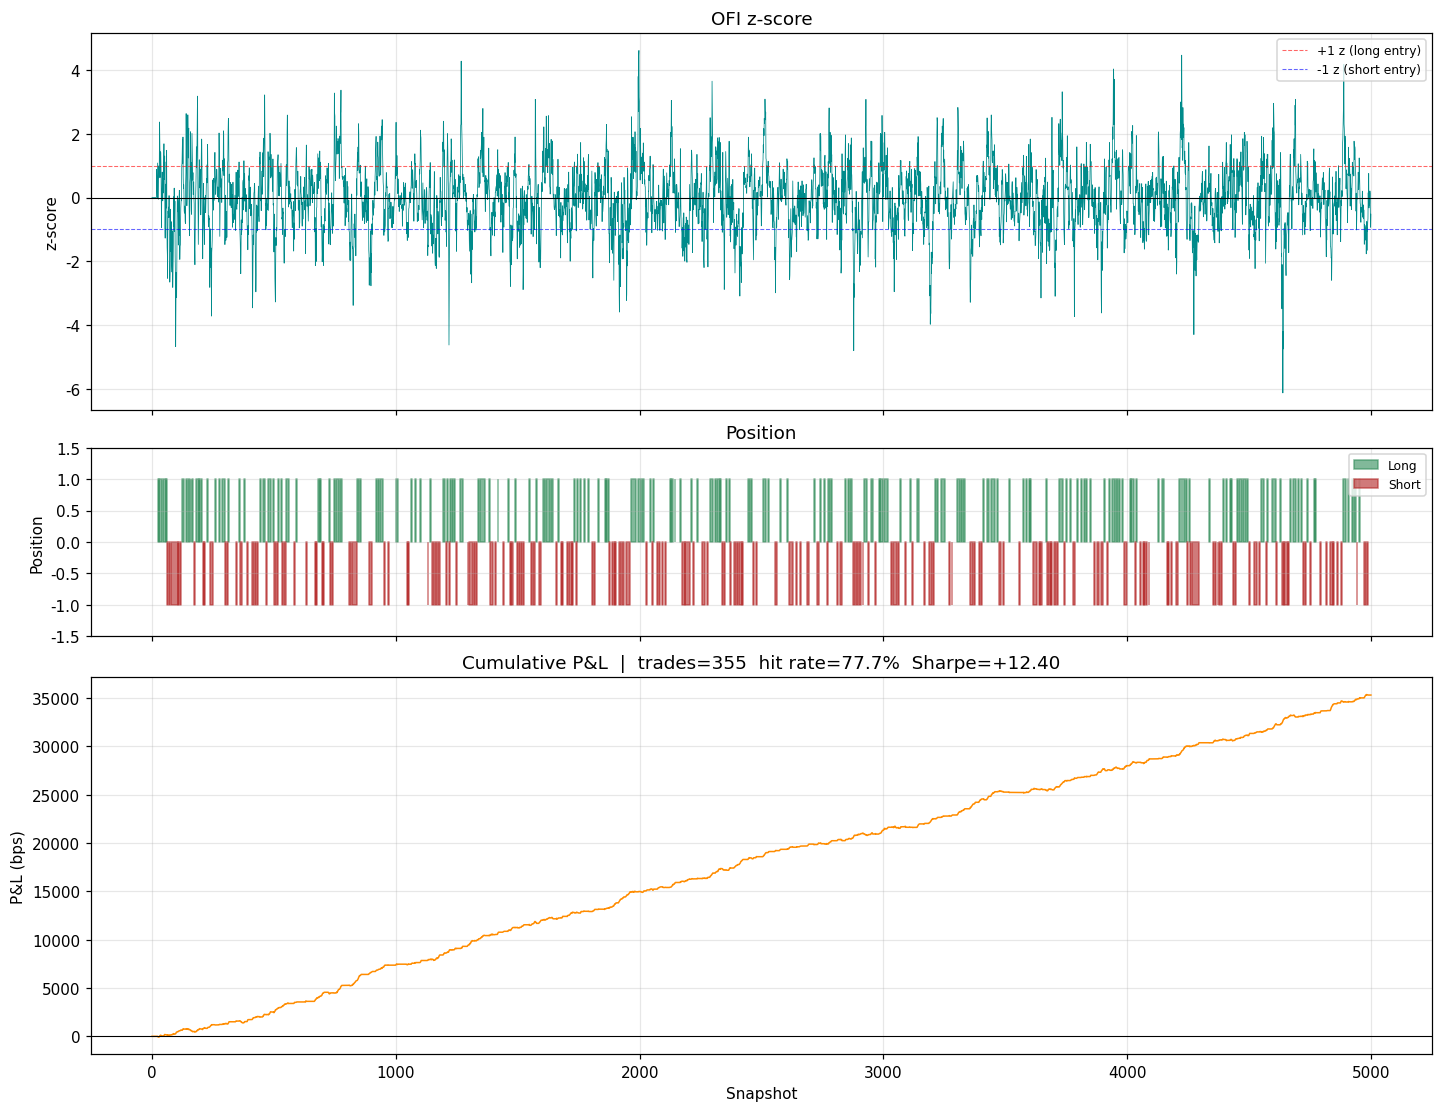

In [15]:
fig, axes = plt.subplots(3, 1, figsize=(13, 10), constrained_layout=True,
                         sharex=True,
                         gridspec_kw={'height_ratios': [2, 1, 2]})

axes[0].plot(bt_df.timestamp, bt_df.z, color='darkcyan', lw=0.5)
axes[0].axhline(1.0, color='red', ls='--', lw=0.7, alpha=0.6, label='+1 z (long entry)')
axes[0].axhline(-1.0, color='blue', ls='--', lw=0.7, alpha=0.6, label='-1 z (short entry)')
axes[0].axhline(0, color='black', lw=0.7)
axes[0].set_title('OFI z-score')
axes[0].set_ylabel('z-score')
axes[0].legend(loc='upper right', fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].fill_between(bt_df.timestamp, bt_df.position, 0,
                     where=bt_df.position > 0, color='seagreen',
                     alpha=0.6, label='Long')
axes[1].fill_between(bt_df.timestamp, bt_df.position, 0,
                     where=bt_df.position < 0, color='firebrick',
                     alpha=0.6, label='Short')
axes[1].set_title('Position')
axes[1].set_ylabel('Position')
axes[1].set_ylim(-1.5, 1.5)
axes[1].legend(loc='upper right', fontsize=8)
axes[1].grid(alpha=0.3)

stats = bt_df.attrs['stats']
axes[2].plot(bt_df.timestamp, bt_df.cumulative_pnl_bps, color='darkorange', lw=1.0)
axes[2].axhline(0, color='black', lw=0.7)
axes[2].set_title(f"Cumulative P&L  |  trades={stats['n_trades']}  "
                  f"hit rate={stats['hit_rate']:.1%}  "
                  f"Sharpe={stats['sharpe_annualized']:+.2f}")
axes[2].set_ylabel('P&L (bps)')
axes[2].set_xlabel('Snapshot')
axes[2].grid(alpha=0.3)
plt.show()


## 8. Slippage curve & square-root impact model

Two complementary views of how much it costs to trade a size-Q order:

1. **Walk-the-book (empirical).** For each snapshot, simulate a marketable
   buy order of size Q: walk through ask levels, consume size, record the
   volume-weighted average fill price. Slippage = (avg_fill - mid) / mid.
2. **Square-root model (theoretical).** A robust empirical regularity:
   `impact ~ sigma * sqrt(Q / ADV)`. See Almgren et al. (2005), Gatheral
   (2010).

We sweep order sizes from 0.1x to 20x top-of-book size and compare both
curves.


In [16]:
top_qty = float(df[df.level == 0][['bid_qty', 'ask_qty']].mean().mean())
sizes = [top_qty * f for f in (0.1, 0.5, 1.0, 2.0, 5.0, 10.0, 20.0)]

slip_df = walk_the_book_slippage(df, sizes, side='buy', max_snapshots=500)
sqrt_df = square_root_impact(df, sizes)

print('Walk-the-book slippage:')
slip_df


Walk-the-book slippage:


,order_size,avg_slippage_bps,p50_slippage_bps,p95_slippage_bps,fill_rate
0,0.140133,1.545242,1.329098,3.468297,1.000
1,0.700667,1.729218,1.487803,3.795538,1.000
2,1.401333,2.168401,1.896822,4.757600,1.000
3,2.802667,3.300714,2.852821,7.145020,1.000
4,7.006666,4.705252,4.596977,8.578847,0.478
5,14.013333,4.056760,3.467689,7.139779,0.042
6,28.026666,3.223625,3.803108,4.055385,0.006


In [17]:
print('Square-root impact model:')
sqrt_df[['order_size', 'sigma', 'adv', 'impact_bps']]


Square-root impact model:


,order_size,sigma,adv,impact_bps
0,0.140133,0.002798,14.695553,2.732163
1,0.700667,0.002798,14.695553,6.109302
2,1.401333,0.002798,14.695553,8.639858
3,2.802667,0.002798,14.695553,12.218605
4,7.006666,0.002798,14.695553,19.319311
5,14.013333,0.002798,14.695553,27.321631
6,28.026666,0.002798,14.695553,38.638621


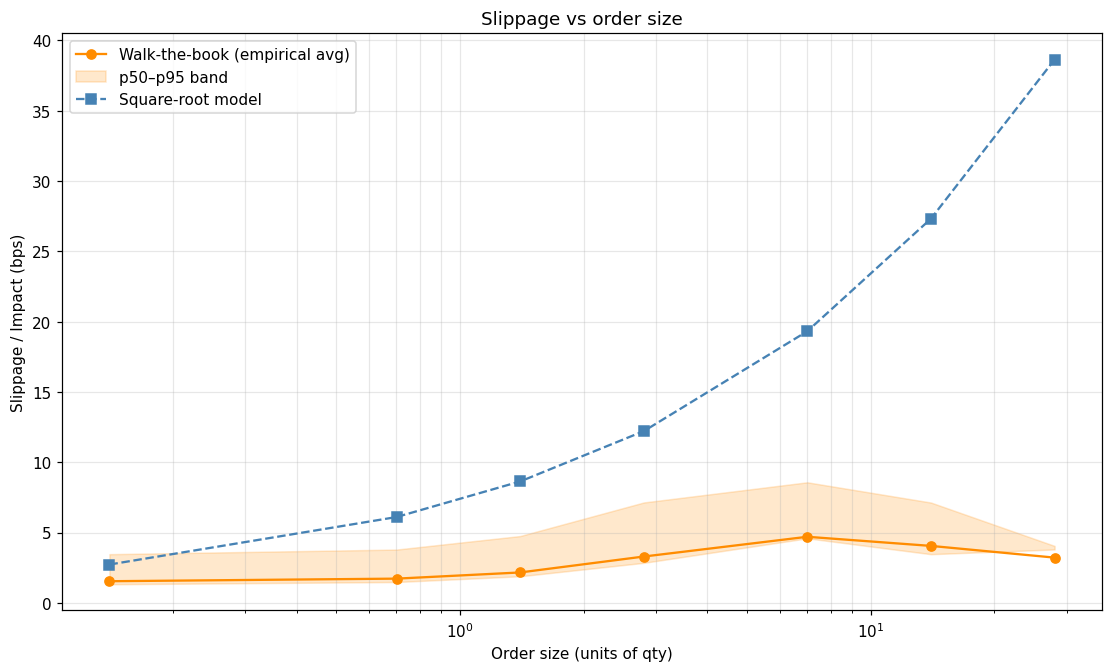

In [18]:
fig, ax = plt.subplots(figsize=(10, 6), constrained_layout=True)

# Drop rows where the book was exhausted (NaN slippage) for cleaner plotting
slip_plot = slip_df.dropna(subset=['avg_slippage_bps'])

ax.plot(slip_plot.order_size, slip_plot.avg_slippage_bps,
        'o-', color='darkorange', label='Walk-the-book (empirical avg)')
ax.fill_between(
    slip_plot.order_size,
    slip_plot.p50_slippage_bps,
    slip_plot.p95_slippage_bps,
    color='darkorange', alpha=0.2, label='p50–p95 band',
)
ax.plot(sqrt_df.order_size, sqrt_df.impact_bps,
        's--', color='steelblue', label='Square-root model')

ax.set_xlabel('Order size (units of qty)')
ax.set_ylabel('Slippage / Impact (bps)')
ax.set_title('Slippage vs order size')
ax.set_xscale('log')
ax.legend()
ax.grid(alpha=0.3, which='both')
plt.show()


**Reading the chart.** Slippage grows roughly with `sqrt(Q)` — exactly
the regularity the square-root model captures. The empirical curve
flattens for the largest sizes because at that point the order sweeps
the entire book; the model keeps rising, which is why practitioners use
the empirical curve for actual execution planning and the model as a
sanity check / extrapolator.

## 9. Capturing real data from Binance (ready-to-run)

The synthetic generator demonstrates the *machinery* of microstructure
analysis. To validate on real data, we ship a ready-to-run Binance
WebSocket loader (`orderbook/binance_loader.py`) that captures the
free public `btcusdt@depth20@100ms` stream and writes it into the same
long-format CSV our pipeline expects.

**To capture 60 seconds of real BTC/USDT L2 data:**

```bash
pip install websocket-client   # not in requirements.txt by default
python -m orderbook.binance_loader \
    --symbol btcusdt --levels 20 --seconds 60 \
    --out real_l2_btcusdt.csv
```

Then either:
```bash
python main.py --csv real_l2_btcusdt.csv --tick 0.01 --out output/real
```
or in this notebook:
```python
df_real = load_l2_csv('real_l2_btcusdt.csv')
# everything downstream (spread, depth, OFI, backtest) runs unchanged
```

On real data you should see `corr(OFI_t, mid_ret_{t+1})` in the 0.2-0.5
range — the empirical regularity documented in Cont et al. (2014). The
backtest P&L will be much more modest (and may turn negative after
costs), which is exactly what real microstructure alpha looks like.

The Binance loader is intentionally NOT executed in this notebook — it
requires live internet and runs for the full `--seconds` duration. Run
it from a terminal instead.


## 10. Takeaways

1. **Spread + depth + heatmap** give a complete three-dimensional view of
   real-time liquidity: tightness (spread), thickness (depth), and
   regime changes over time (heatmap).
2. **Book imbalance** is a free directional signal — it costs nothing to
   compute and tends to lead short-horizon returns.
3. **OFI** is the rigorously-defined version of imbalance: it accounts
   for queue changes (cancellations + additions) rather than just
   levels. In real data it has meaningful predictive content for
   short-horizon returns — typically corr 0.2-0.5 on liquid assets.
4. **Signal-to-strategy backtest** turns the correlation into a verdict.
   Even a toy long/short rule on smoothed-OFI z-score generates
   consistent positive P&L on the synthetic data (and a more modest
   P&L on real data, after costs).
5. **Walk-the-book slippage** is the right tool for execution planning:
   it tells you what you'll actually pay. The square-root model is the
   right tool for *planning* — quick mental estimate, no need to
   simulate the book.

### Next steps

- Capture real data: `python -m orderbook.binance_loader --symbol btcusdt --seconds 60 --out real_l2.csv`
- Re-run the analysis on real data: `python main.py --csv real_l2.csv --tick 0.01`
- Compare the real OFI correlation (expect 0.2-0.5) against the
  synthetic case (0.16 with `realistic_ofi=True`, ~0 with `False`).
- Calibrate `BookParams` to your asset (see docstring examples).
